<a href="https://colab.research.google.com/github/RoktimBailung/Image-transform-application/blob/main/Resnet101_%2B_LSTM_Roktim_Kumar_Bailung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1: Setup and Data Preparation

In [ ]:
# Import essential libraries
import os
import json
import requests
from collections import Counter, defaultdict
from tqdm import tqdm
import numpy as np

# PyTorch and torchvision imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

# NLTK for text processing
import nltk
nltk.download('punkt')

# For displaying images and plots
from PIL import Image
import matplotlib.pyplot as plt

# Set the device to GPU (cuda) if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Using device: cuda


Mount Google Drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


Define File Paths

In [ ]:
# Define the base path to Flickr8k dataset in Google Drive
BASE_PATH = '/content/drive/MyDrive/flickr8k/'

# Define paths to the images folder and the captions file
IMAGE_PATH = os.path.join(BASE_PATH, 'Images')
CAPTIONS_FILE = os.path.join(BASE_PATH, 'captions.txt')

# Verify by checking if the paths exist
if os.path.exists(IMAGE_PATH) and os.path.exists(CAPTIONS_FILE):
    print("✅ Paths verified.")
    print(f"Found {len(os.listdir(IMAGE_PATH))} images.")
else:
    print("❌ Error: Please check your IMAGE_PATH and CAPTIONS_FILE.")

✅ Paths verified.
Found 8099 images.


Download Karpathy Split File

In [ ]:
# Use the corrected wget command to download the Karpathy split JSON file
!wget -c "https://github.com/Delphboy/karpathy-splits/raw/main/dataset_flickr8k.json?download=" -O dataset_flickr8k.json

# Verify the download
if os.path.exists('dataset_flickr8k.json'):
    print("✅ Karpathy JSON split file downloaded successfully.")
else:
    print("❌ File download failed. Please check the command and your connection.")

--2025-07-27 12:07:45--  https://github.com/Delphboy/karpathy-splits/raw/main/dataset_flickr8k.json?download=
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/Delphboy/karpathy-splits/main/dataset_flickr8k.json?download=true [following]
--2025-07-27 12:07:45--  https://media.githubusercontent.com/media/Delphboy/karpathy-splits/main/dataset_flickr8k.json?download=true
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26366460 (25M) [application/octet-stream]
Saving to: ‘dataset_flickr8k.json’

dataset_flickr8k.js 100%[===================>]  25.14M  --.-KB/s    in 0.06s   

2025-0

Load and Parse Captions

In [ ]:
def load_captions(filepath):
    """
    Loads captions from the provided text file.
    Skips the header and handles the 'image,caption' format.
    """
    captions_map = defaultdict(list)
    with open(filepath, 'r') as f:
        # Skip the header line
        next(f)
        for line in f:
            try:
                # Split the line at the first comma only
                image_name, caption = line.strip().split(',', 1)
                captions_map[image_name].append(caption)
            except ValueError:
                print(f"Skipping malformed line: {line.strip()}")
    return dict(captions_map)

# Load all captions from the file
all_captions = load_captions(CAPTIONS_FILE)
print(f"✅ Loaded captions for {len(all_captions)} unique images.")
# Print a sample
sample_image = list(all_captions.keys())[0]
print(f"\nSample captions for '{sample_image}':")
for cap in all_captions[sample_image]:
    print(f"- {cap}")

✅ Loaded captions for 8091 unique images.

Sample captions for '1000268201_693b08cb0e.jpg':
- A child in a pink dress is climbing up a set of stairs in an entry way .
- A girl going into a wooden building .
- A little girl climbing into a wooden playhouse .
- A little girl climbing the stairs to her playhouse .
- A little girl in a pink dress going into a wooden cabin .


Load Karpathy Splits and Create Datasets

In [ ]:
# Load the JSON file
with open('dataset_flickr8k.json', 'r') as f:
    karpathy_split = json.load(f)

# Create dictionaries for train, validation, and test captions
train_captions = {}
val_captions = {}
test_captions = {}

print("Splitting dataset...")
for img_data in tqdm(karpathy_split['images']):
    filename = img_data['filename']
    split = img_data['split']

    if filename in all_captions:
        if split == 'train':
            train_captions[filename] = all_captions[filename]
        elif split == 'val':
            val_captions[filename] = all_captions[filename]
        elif split == 'test':
            test_captions[filename] = all_captions[filename]

print("\n✅ Dataset split complete.")
print(f"Training images:   {len(train_captions)}")
print(f"Validation images: {len(val_captions)}")
print(f"Testing images:    {len(test_captions)}")

Splitting dataset...


100%|██████████| 8000/8000 [00:00<00:00, 487150.39it/s]


✅ Dataset split complete.
Training images:   6000
Validation images: 1000
Testing images:    1000


## Phase 2: Feature Extraction & Vocabulary

Create the Vocabulary Class

In [ ]:
class Vocabulary:
    def __init__(self, freq_threshold):
        # Initialize containers for word-to-index and index-to-word mappings
        # and special tokens
        self.itos = {0: "<PAD>", 1: "<START>", 2: "<END>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        """A simple tokenizer using NLTK."""
        return [tok.lower() for tok in nltk.word_tokenize(text)]

    def build_vocabulary(self, sentence_list):
        """Builds the vocabulary from a list of sentences."""
        frequencies = Counter()
        idx = 4  # Start indexing from 4, as 0-3 are special tokens

        # Calculate frequency of each word
        for sentence in tqdm(sentence_list, desc="Building Vocab"):
            for word in self.tokenize(sentence):
                frequencies[word] += 1

                # Add word to vocab if it meets the frequency threshold
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        """Converts a text sentence into a sequence of numerical indices."""
        tokenized_text = self.tokenize(text)
        # Return a list of indices, using the <UNK> token for unknown words
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized_text]

print("✅ Vocabulary class defined.")

✅ Vocabulary class defined.


 Build and Save the Vocabulary

In [ ]:
# Download the necessary NLTK resource to fix the LookupError
import nltk
nltk.download('punkt_tab')

# Create a flat list of all training captions
all_train_captions = [caption for caps_list in train_captions.values() for caption in caps_list]

# Initialize and build the vocabulary
# A word must appear at least 5 times to be included
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(all_train_captions)

# Save the vocabulary to a file in your Drive
vocab_path = os.path.join(BASE_PATH, 'vocab.pt')
torch.save(vocab, vocab_path)

print(f"\n✅ Vocabulary created and saved successfully.")
print(f"Vocabulary size: {len(vocab)}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
Building Vocab: 100%|██████████| 30000/30000 [00:02<00:00, 11159.64it/s]


✅ Vocabulary created and saved successfully.
Vocabulary size: 2551


Initialize the ResNet-101 Encoder

In [ ]:
# Define image transformations
# These must match the standard transformations for ImageNet models
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load the pretrained ResNet-101 model
resnet101 = models.resnet101(pretrained=True)

# Freeze all the parameters in the model
for param in resnet101.parameters():
    param.requires_grad_(False)

# Remove the last two layers (avgpool and fc) to get spatial features
# The output of the sequential model will be our feature map
modules = list(resnet101.children())[:-2]
encoder = nn.Sequential(*modules)
encoder.to(device)
encoder.eval() # Set to evaluation mode

print("✅ ResNet-101 encoder initialized and moved to device.")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:01<00:00, 124MB/s]


✅ ResNet-101 encoder initialized and moved to device.


Define and Run Feature Extraction


In [ ]:
# Define the directory to save extracted features
FEATURES_PATH = os.path.join(BASE_PATH, 'features_resnet101')
os.makedirs(FEATURES_PATH, exist_ok=True)
print(f"Features will be saved to: {FEATURES_PATH}")

# Get a list of all image filenames
all_image_filenames = list(all_captions.keys())

print("\nStarting feature extraction...")
# Loop through all images and extract features
for image_filename in tqdm(all_image_filenames, desc="Extracting Features"):
    feature_file_path = os.path.join(FEATURES_PATH, image_filename.replace('.jpg', '.pt'))

    # Check if the feature file already exists to avoid re-computation
    if os.path.exists(feature_file_path):
        continue

    try:
        # Construct the full image path
        image_path = os.path.join(IMAGE_PATH, image_filename)

        # Load and transform the image
        image = Image.open(image_path).convert("RGB")
        image_tensor = transform(image).unsqueeze(0).to(device) # Add batch dimension and move to device

        # Pass image through the encoder
        with torch.no_grad():
            features = encoder(image_tensor) # Shape: (1, 2048, 7, 7)

        # Save the feature tensor (move to CPU first)
        torch.save(features.squeeze(0).cpu(), feature_file_path)

    except Exception as e:
        print(f"\nError processing {image_filename}: {e}")

print("\n✅ Feature extraction complete!")

Features will be saved to: /content/drive/MyDrive/flickr8k/features_resnet101

Starting feature extraction...


Extracting Features: 100%|██████████| 8091/8091 [1:43:56<00:00,  1.30it/s]


✅ Feature extraction complete!


 Verify Feature Extraction

In [ ]:
# Path where features were saved
FEATURES_PATH = os.path.join(BASE_PATH, 'features_resnet101')

# The total number of images we expect features for
total_images = len(all_captions.keys())

# Get a list of all saved feature files
saved_features = [f for f in os.listdir(FEATURES_PATH) if f.endswith('.pt')]
num_saved_features = len(saved_features)

print(f"Total images in dataset: {total_images}")
print(f"Features saved in Drive: {num_saved_features}")

# --- Verification ---
if num_saved_features == total_images:
    print("\n✅ Success! All image features have been extracted and saved correctly.")
else:
    print(f"\n❌ Warning! Mismatch found.")
    print(f"You are missing {total_images - num_saved_features} feature files.")

    # Optional: List a few missing files to help debug
    print("\nChecking for specific missing files...")
    missing_files = []
    all_image_filenames = list(all_captions.keys())
    for image_filename in all_image_filenames:
        feature_filename = image_filename.replace('.jpg', '.pt')
        if feature_filename not in saved_features:
            missing_files.append(image_filename)

    if missing_files:
        print(f"Found missing features for (example): {missing_files[:5]}")
        print("You may need to re-run the feature extraction cell (Phase 2, Cell 4).")

Total images in dataset: 8091
Features saved in Drive: 8091

✅ Success! All image features have been extracted and saved correctly.


## Phase 3: Custom Dataset and DataLoaders

Create the Custom Dataset Class

In [ ]:
class FlickrDataset(Dataset):
    """
    Custom PyTorch Dataset for loading pre-extracted features and captions.
    """
    def __init__(self, captions_dict, features_path, vocab):
        self.captions_dict = captions_dict
        self.features_path = features_path
        self.vocab = vocab

        # We need a list of image filenames to index into the dataset
        self.img_filenames = list(captions_dict.keys())

    def __len__(self):
        # The total number of samples is the number of images
        return len(self.img_filenames)

    def __getitem__(self, index):
        # Get the image filename for the given index
        img_filename = self.img_filenames[index]

        # Load the pre-extracted feature tensor
        feature_filepath = os.path.join(self.features_path, img_filename.replace('.jpg', '.pt'))
        features = torch.load(feature_filepath)

        # Get the list of 5 captions for this image and select one randomly
        # This provides more variety during training
        caption = np.random.choice(self.captions_dict[img_filename])

        # Numericalize the caption using the vocabulary
        # Add <START> and <END> tokens
        numericalized_caption = [self.vocab.stoi["<START>"]]
        numericalized_caption.extend(self.vocab.numericalize(caption))
        numericalized_caption.append(self.vocab.stoi["<END>"])

        return features, torch.tensor(numericalized_caption)

print("✅ FlickrDataset class defined.")

✅ FlickrDataset class defined.


Create the Collate Function

In [ ]:
from torch.nn.utils.rnn import pad_sequence

class Collate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        # Separate features and captions from the batch
        features = [item[0].unsqueeze(0) for item in batch]
        captions = [item[1] for item in batch]

        # Stack all feature tensors along a new dimension (the batch dimension)
        features = torch.cat(features, dim=0)

        # Pad captions to the length of the longest caption in the batch
        captions_padded = pad_sequence(captions, batch_first=True, padding_value=self.pad_idx)

        return features, captions_padded

print("✅ Collate class defined.")

✅ Collate class defined.


Instantiate DataLoaders for Each Split

In [ ]:
# Define batch size
BATCH_SIZE = 32

# Path to the saved features directory
FEATURES_PATH = os.path.join(BASE_PATH, 'features_resnet101')

# Get the padding index from our vocabulary
pad_idx = vocab.stoi["<PAD>"]

# Create the collate function instance
collate_fn = Collate(pad_idx=pad_idx)

# --- Create DataLoaders ---

# Training DataLoader
train_dataset = FlickrDataset(captions_dict=train_captions, features_path=FEATURES_PATH, vocab=vocab)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle training data
    collate_fn=collate_fn
)

# Validation DataLoader
val_dataset = FlickrDataset(captions_dict=val_captions, features_path=FEATURES_PATH, vocab=vocab)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle validation data
    collate_fn=collate_fn
)

# Test DataLoader
test_dataset = FlickrDataset(captions_dict=test_captions, features_path=FEATURES_PATH, vocab=vocab)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle test data
    collate_fn=collate_fn
)

print("✅ DataLoaders created successfully.")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

✅ DataLoaders created successfully.
Number of training batches: 188
Number of validation batches: 32
Number of testing batches: 32



## Phase 4: The "Show, Attend, and Tell" Model Architecture


The Attention Module

In [ ]:
class Attention(nn.Module):
    """
    Bahdanau-style Attention module.
    """
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        # Linear layer to transform encoded image features
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        # Linear layer to transform decoder's previous hidden state
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        # Linear layer to compute the attention score (e)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out shape: (batch_size, num_pixels, encoder_dim)
        # decoder_hidden shape: (batch_size, decoder_dim)

        att1 = self.encoder_att(encoder_out)  # (batch_size, num_pixels, attention_dim)
        att2 = self.decoder_att(decoder_hidden) # (batch_size, attention_dim)

        # Add the two attention parts together (broadcasting att2)
        # att2.unsqueeze(1) shape: (batch_size, 1, attention_dim)
        attention_scores = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2) # (batch_size, num_pixels)

        # Apply softmax to get the attention weights (alpha)
        alpha = self.softmax(attention_scores) # (batch_size, num_pixels)

        # Compute the context vector (weighted sum of encoder outputs)
        # alpha.unsqueeze(2) shape: (batch_size, num_pixels, 1)
        context_vector = (encoder_out * alpha.unsqueeze(2)).sum(dim=1) # (batch_size, encoder_dim)

        return context_vector, alpha

print("✅ Attention class defined.")

✅ Attention class defined.


The Decoder with Attention Module

In [ ]:
# --- CORRECTED DecoderWithAttention CLASS (Phase 4, Cell 2) ---

class DecoderWithAttention(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, encoder_dim=2048, attention_dim=512, dropout=0.5):
        super(DecoderWithAttention, self).__init__()
        self.encoder_dim = encoder_dim
        self.attention_dim = attention_dim
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.embed_size = embed_size

        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(p=dropout)
        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)

        self.init_weights()

    def init_weights(self):
        self.embedding.weight.data.uniform_(-0.1, 0.1)
        self.fc.bias.data.fill_(0)
        self.fc.weight.data.uniform_(-0.1, 0.1)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, captions, caption_lengths):
        batch_size = encoder_out.size(0)

        # --- FIX STARTS HERE ---
        # The encoder_out has shape (batch_size, 2048, 7, 7). We need to permute and flatten it
        # to (batch_size, 49, 2048) for the attention mechanism.
        encoder_out = encoder_out.permute(0, 2, 3, 1)  # (batch_size, 7, 7, 2048)
        encoder_out = encoder_out.view(batch_size, -1, self.encoder_dim)  # (batch_size, 49, 2048)
        num_pixels = encoder_out.size(1) # num_pixels is now correctly 49
        # --- FIX ENDS HERE ---

        caption_lengths, sort_ind = caption_lengths.sort(dim=0, descending=True)
        encoder_out = encoder_out[sort_ind]
        captions = captions[sort_ind]

        embeddings = self.embedding(captions)
        h, c = self.init_hidden_state(encoder_out)
        decode_lengths = (caption_lengths - 1).tolist()

        predictions = torch.zeros(batch_size, max(decode_lengths), self.vocab_size).to(device)
        alphas = torch.zeros(batch_size, max(decode_lengths), num_pixels).to(device)

        for t in range(max(decode_lengths)):
            batch_size_t = sum([l > t for l in decode_lengths])
            context_vector, alpha = self.attention(encoder_out[:batch_size_t], h[:batch_size_t])
            lstm_input = torch.cat((embeddings[:batch_size_t, t, :], context_vector), dim=1)
            h, c = self.lstm_cell(lstm_input, (h[:batch_size_t], c[:batch_size_t]))
            preds = self.fc(self.dropout(h))
            predictions[:batch_size_t, t, :] = preds
            alphas[:batch_size_t, t, :] = alpha

        return predictions, captions, decode_lengths, sort_ind

Define Hyperparameters and Instantiate the Model

In [ ]:
# Model Hyperparameters
embed_size = 256
hidden_size = 512
attention_dim = 512
vocab_size = len(vocab)
encoder_dim = 2048 # From ResNet-101
dropout = 0.5

# Instantiate the decoder
decoder = DecoderWithAttention(
    embed_size=embed_size,
    hidden_size=hidden_size,
    vocab_size=vocab_size,
    attention_dim=attention_dim,
    encoder_dim=encoder_dim,
    dropout=dropout
).to(device)

print("✅ Decoder model instantiated successfully.")
# You can print the model to see its structure
# print(decoder)

✅ Decoder model instantiated successfully.


## Phase 5: Training the Model

Define Hyperparameters and Helper Functions

In [ ]:
from torch.nn.utils.rnn import pack_padded_sequence

# Training Hyperparameters
num_epochs = 20
learning_rate = 4e-4

# Early stopping parameters
patience = 5
epochs_no_improve = 0
min_val_loss = float('inf')

# Path to save checkpoints
CHECKPOINT_PATH = os.path.join(BASE_PATH, 'checkpoints')
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# Define optimizer and loss function
optimizer = torch.optim.Adam(params=decoder.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])


def save_checkpoint(state, filename="my_checkpoint.pth.tar"):
    """Saves the model checkpoint."""
    print("=> Saving checkpoint")
    torch.save(state, os.path.join(CHECKPOINT_PATH, filename))

print("✅ Training parameters and helper functions are ready.")

✅ Training parameters and helper functions are ready.


The Main Training and Validation Loop

In [ ]:
# Start Training
print("🚀 Starting Training...")

for epoch in range(num_epochs):

    # --- Training ---
    decoder.train()
    train_loss = 0.0

    # Wrap train_loader with tqdm for a progress bar
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    for idx, (features, captions) in enumerate(loop):
        features = features.to(device)
        captions = captions.to(device)

        # Get caption lengths for packing
        caption_lengths = torch.sum(captions != vocab.stoi["<PAD>"], dim=1)

        # Forward pass
        scores, captions_sorted, decode_lengths, sort_ind = decoder(features, captions, caption_lengths)

        # Since we decoded starting with <START>, the targets are all words after <START>
        targets = captions_sorted[:, 1:]

        # Pack the sequences to ignore padding in loss calculation
        scores_packed = pack_padded_sequence(scores, decode_lengths, batch_first=True).data
        targets_packed = pack_padded_sequence(targets, decode_lengths, batch_first=True).data

        # Calculate the loss
        loss = criterion(scores_packed, targets_packed)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=0.5)
        optimizer.step()

        train_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- Validation ---
    decoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, captions in val_loader:
            features = features.to(device)
            captions = captions.to(device)
            caption_lengths = torch.sum(captions != vocab.stoi["<PAD>"], dim=1)

            scores, captions_sorted, decode_lengths, sort_ind = decoder(features, captions, caption_lengths)
            targets = captions_sorted[:, 1:]

            scores_packed = pack_padded_sequence(scores, decode_lengths, batch_first=True).data
            targets_packed = pack_padded_sequence(targets, decode_lengths, batch_first=True).data

            loss = criterion(scores_packed, targets_packed)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- Checkpoint Saving ---
    # Create a state dictionary
    state = {
        'epoch': epoch + 1,
        'decoder_state_dict': decoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'vocab': vocab,
        'val_loss': avg_val_loss,
    }

    # Save a checkpoint after every epoch
    checkpoint_filename = f"checkpoint_epoch_{epoch+1}.pth.tar"
    save_checkpoint(state, filename=checkpoint_filename)

    # Early stopping logic
    if avg_val_loss < min_val_loss:
        print(f"Validation loss decreased ({min_val_loss:.4f} --> {avg_val_loss:.4f}). Saving model as BEST.")
        min_val_loss = avg_val_loss
        epochs_no_improve = 0
        save_checkpoint(state, filename="BEST_checkpoint.pth.tar")
    else:
        epochs_no_improve += 1
        print(f"Validation loss did not improve. Patience: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

print("\n✅ Training complete.")

🚀 Starting Training...


Epoch [1/20]: 100%|██████████| 188/188 [00:59<00:00,  3.17it/s, loss=4.18]


Epoch 1/20 | Train Loss: 4.7616 | Val Loss: 4.0605
=> Saving checkpoint
Validation loss decreased (inf --> 4.0605). Saving model as BEST.
=> Saving checkpoint


Epoch [2/20]: 100%|██████████| 188/188 [00:49<00:00,  3.81it/s, loss=3.82]


Epoch 2/20 | Train Loss: 3.9456 | Val Loss: 3.6644
=> Saving checkpoint
Validation loss decreased (4.0605 --> 3.6644). Saving model as BEST.
=> Saving checkpoint


...

Epoch 18/20 | Train Loss: 2.6625 | Val Loss: 2.8355
=> Saving checkpoint
Validation loss did not improve. Patience: 1/5


Epoch [19/20]: 100%|██████████| 188/188 [00:40<00:00,  4.59it/s, loss=2.83]


Epoch 19/20 | Train Loss: 2.6206 | Val Loss: 2.7690
=> Saving checkpoint
Validation loss decreased (2.7927 --> 2.7690). Saving model as BEST.
=> Saving checkpoint


Epoch [20/20]: 100%|██████████| 188/188 [00:43<00:00,  4.29it/s, loss=2.61]


Epoch 20/20 | Train Loss: 2.5902 | Val Loss: 2.7507
=> Saving checkpoint
Validation loss decreased (2.7690 --> 2.7507). Saving model as BEST.
=> Saving checkpoint

✅ Training complete.


## Phase 6: Inference and Evaluation


Install Evaluation Libraries

In [ ]:
# 1. Install pycocoevalcap and its dependencies
!pip install git+https://github.com/salaniz/pycocoevalcap

# 2. Download WordNet for the METEOR score
import nltk
nltk.download('wordnet')

# 3. Manually download and set up SPICE models
import os
os.environ['SPICE_MODELS'] = '/content/spice/models'
!mkdir -p /content/spice/
!wget https://repo1.maven.org/maven2/edu/stanford/nlp/stanford-corenlp/3.6.0/stanford-corenlp-3.6.0.jar -O /content/spice/stanford-corenlp-3.6.0.jar
!wget https://repo1.maven.org/maven2/edu/stanford/nlp/stanford-corenlp/3.6.0/stanford-corenlp-3.6.0-models.jar -O /content/spice/stanford-corenlp-3.6.0-models.jar

print("✅ Evaluation libraries and models installed.")

  Cloning https://github.com/salaniz/pycocoevalcap to /tmp/pip-req-build-6iux6q7i
  Running command git clone --filter=blob:none --quiet https://github.com/salaniz/pycocoevalcap /tmp/pip-req-build-6iux6q7i
  Resolved https://github.com/salaniz/pycocoevalcap to commit a24f74c408c918f1f4ec34e9514bc8a76ce41ffd
  Preparing metadata (setup.py) ... done
  Created wheel for pycocoevalcap: filename=pycocoevalcap-1.2-py3-none-any.whl size=104312245 sha256=6f49c7cfae5bbac01f63b8c3ce81a339988ce4662476405f5e678e8268f7fa17
  Stored in directory: /tmp/pip-ephem-wheel-cache-el1atp72/wheels/d2/1f/44/6485e566f8ae3d42b56e7c05fd50a3bbb70a50b0e6e7c55212
Successfully built pycocoevalcap


[nltk_data] Downloading package wordnet to /root/nltk_data...


--2025-07-27 14:38:08--  https://repo1.maven.org/maven2/edu/stanford/nlp/stanford-corenlp/3.6.0/stanford-corenlp-3.6.0.jar
Resolving repo1.maven.org (repo1.maven.org)... 199.232.192.209, 199.232.196.209, 2a04:4e42:4c::209, ...
Connecting to repo1.maven.org (repo1.maven.org)|199.232.192.209|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7270741 (6.9M) [application/java-archive]
Saving to: ‘/content/spice/stanford-corenlp-3.6.0.jar’

/content/spice/stan 100%[===================>]   6.93M  5.12MB/s    in 1.4s    

2025-07-27 14:38:11 (5.12 MB/s) - ‘/content/spice/stanford-corenlp-3.6.0.jar’ saved [7270741/7270741]

--2025-07-27 14:38:11--  https://repo1.maven.org/maven2/edu/stanford/nlp/stanford-corenlp/3.6.0/stanford-corenlp-3.6.0-models.jar
Resolving repo1.maven.org (repo1.maven.org)... 199.232.192.209, 199.232.196.209, 2a04:4e42:4c::209, ...
Connecting to repo1.maven.org (repo1.maven.org)|199.232.192.209|:443... connected.
HTTP request sent, awaiting response

 Load the Best Model Checkpoint

In [ ]:
# --- CORRECTED CODE (Phase 6, Cell 2) ---

# --- Load the best model ---
checkpoint_path = os.path.join(CHECKPOINT_PATH, "BEST_checkpoint.pth.tar")

# Load the checkpoint from the file, explicitly setting weights_only=False
# This is necessary in PyTorch 2.6+ to load checkpoints containing custom classes.
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Load the vocabulary from the checkpoint
vocab = checkpoint['vocab']

# Re-create the model with the saved hyperparameters
decoder = DecoderWithAttention(
    embed_size=256,
    hidden_size=512,
    attention_dim=512,
    vocab_size=len(vocab),
    encoder_dim=2048,
    dropout=0.5
).to(device)

# Load the trained weights into the model
decoder.load_state_dict(checkpoint['decoder_state_dict'])
decoder.eval() # Set the model to evaluation mode

print("✅ Best model and vocabulary loaded successfully.")

✅ Best model and vocabulary loaded successfully.


Define the Caption Generation Function (with Beam Search)

In [ ]:
def generate_caption_beam_search(features, vocab, beam_size=5):
    """
    Generates a caption for an image using beam search.
    """
    # Reshape and prepare features for the decoder
    features = features.permute(0, 2, 3, 1) # (1, 7, 7, 2048)
    features = features.view(1, -1, decoder.encoder_dim) # (1, 49, 2048)

    # Initialize LSTM state
    h, c = decoder.init_hidden_state(features)

    # Start with a list of sequences, each containing just the <START> token.
    # Each sequence has a score (log probability), initially 0.
    start_token = vocab.stoi['<START>']
    initial_sequences = [[[start_token], 0.0]] # [sequence, score]

    # Run beam search
    for _ in range(30): # Max caption length
        all_candidates = []

        # Expand each current sequence
        for seq, score in initial_sequences:
            # If the last token is <END>, this sequence is complete
            if seq[-1] == vocab.stoi['<END>']:
                all_candidates.append([seq, score])
                continue

            # Get the last hidden state and token to predict the next word
            last_word = torch.tensor([seq[-1]], device=device)
            embedded_word = decoder.embedding(last_word)

            context, _ = decoder.attention(features, h)
            lstm_input = torch.cat([embedded_word, context], dim=1)
            h, c = decoder.lstm_cell(lstm_input, (h, c))

            # Get the predictions (log probabilities)
            output = decoder.fc(h)
            log_probs = torch.log_softmax(output, dim=1)

            # Get the top 'beam_size' next words
            top_log_probs, top_indices = log_probs.topk(beam_size)

            # Create new sequences with the new words
            for i in range(beam_size):
                new_seq = seq + [top_indices[0][i].item()]
                new_score = score - top_log_probs[0][i].item() # Use negative log prob
                all_candidates.append([new_seq, new_score])

        # Select the top 'beam_size' sequences from all candidates
        ordered = sorted(all_candidates, key=lambda x: x[1])
        initial_sequences = ordered[:beam_size]

    # The best sequence is the one with the lowest score
    best_seq = initial_sequences[0][0]

    # Convert indices back to words
    caption_words = [vocab.itos[idx] for idx in best_seq if idx not in {vocab.stoi['<START>'], vocab.stoi['<END>'], vocab.stoi['<PAD>']}]

    return ' '.join(caption_words)

print("✅ Beam Search captioning function defined.")

✅ Beam Search captioning function defined.


Generate and Display a Caption

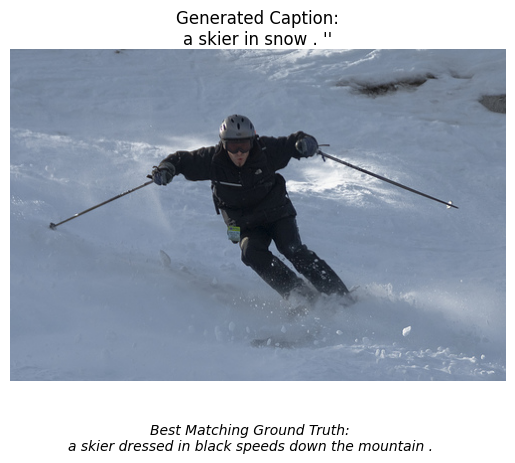

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from nltk.translate.bleu_score import sentence_bleu

# Get a random image from the test set
random_img_filename = random.choice(list(test_captions.keys()))
image_path = os.path.join(IMAGE_PATH, random_img_filename)

# Load its pre-extracted features
feature_path = os.path.join(FEATURES_PATH, random_img_filename.replace('.jpg', '.pt'))
features = torch.load(feature_path).unsqueeze(0).to(device)

# --- Generate the caption using Beam Search ---
generated_caption = generate_caption_beam_search(features, vocab, beam_size=5)
tokenized_generated = generated_caption.split()

# --- Find the best matching ground truth caption ---
ground_truths = test_captions[random_img_filename]
best_gt_caption = ""
highest_bleu_score = 0

for gt_caption in ground_truths:
    tokenized_gt = gt_caption.split()
    # Calculate BLEU-4 score for this pair
    bleu_score = sentence_bleu([tokenized_gt], tokenized_generated, weights=(0.25, 0.25, 0.25, 0.25))

    if bleu_score > highest_bleu_score:
        highest_bleu_score = bleu_score
        best_gt_caption = gt_caption

# --- Display the results ---
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')

# Display the model's generated caption
plt.title(f"Generated Caption:\n{generated_caption}", fontsize=12, wrap=True)

# Display the best matching ground truth caption below the image
plt.figtext(0.5, 0.01, f"Best Matching Ground Truth:\n{best_gt_caption}", ha="center", fontsize=10, style='italic', wrap=True)

plt.show()

Caption Generation for randomly selected image from Google Drive.

Predicting for image: /content/drive/MyDrive/793558.jpg


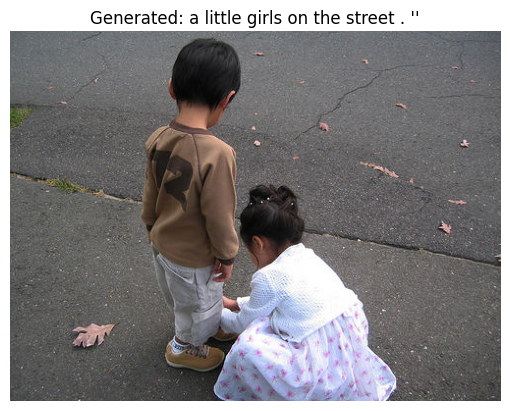

In [ ]:
# The predict_caption function must be defined before it can be used.

def predict_caption(image_path, beam_size=5):
    """
    Generates a caption for a single image.
    """
    # Image transformations
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Load and process the image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Extract features using the globally defined 'encoder'
    with torch.no_grad():
        features = encoder(image_tensor)

    # --- Beam Search ---
    # Reshape features for the decoder
    features = features.permute(0, 2, 3, 1)
    features = features.view(1, -1, decoder.encoder_dim)

    # Initialize LSTM state and starting sequence
    h, c = decoder.init_hidden_state(features)
    start_token = vocab.stoi['<START>']
    initial_sequences = [[[start_token], 0.0]]

    # Loop to generate the caption
    for _ in range(30): # Max caption length
        all_candidates = []
        for seq, score in initial_sequences:
            if seq[-1] == vocab.stoi['<END>']:
                all_candidates.append([seq, score])
                continue

            last_word = torch.tensor([seq[-1]], device=device)
            embedded_word = decoder.embedding(last_word)
            context, _ = decoder.attention(features, h)
            lstm_input = torch.cat([embedded_word, context], dim=1)
            h, c = decoder.lstm_cell(lstm_input, (h, c))
            output = decoder.fc(h)
            log_probs = torch.log_softmax(output, dim=1)
            top_log_probs, top_indices = log_probs.topk(beam_size)

            for i in range(beam_size):
                new_seq = seq + [top_indices[0][i].item()]
                new_score = score - top_log_probs[0][i].item()
                all_candidates.append([new_seq, new_score])

        ordered = sorted(all_candidates, key=lambda x: x[1])
        initial_sequences = ordered[:beam_size]

    # Get the best sequence and convert it to a string
    best_seq = initial_sequences[0][0]
    caption_words = [vocab.itos[idx] for idx in best_seq if idx not in {vocab.stoi['<START>'], vocab.stoi['<END>'], vocab.stoi['<PAD>']}]
    return ' '.join(caption_words)


# --- NOW, USE THE FUNCTION ---

# IMPORTANT: Change the path on the line below
image_path_to_predict = "/content/drive/MyDrive/793558.jpg" # <--- YOUR IMAGE PATH

print(f"Predicting for image: {image_path_to_predict}")

try:
    # Generate the caption
    generated_caption = predict_caption(image_path_to_predict)

    # Display the image and the generated caption
    image = Image.open(image_path_to_predict)
    plt.imshow(image)
    plt.title(f"Generated: {generated_caption}", wrap=True)
    plt.axis("off")
    plt.show()

except FileNotFoundError:
    print(f"❌ Error: File not found at the specified path.")
    print("Please make sure the path is correct and the image exists in your Google Drive.")

Full Evaluation on Test Set

In [ ]:
# --- CORRECTED CODE (Phase 6, Cell 5) ---

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice

def evaluate_model():
    decoder.eval()

    # Dictionaries to store predictions and ground truths
    predictions = {}
    ground_truths = {}

    # Use image filenames as keys (as the library supports strings)
    image_ids = list(test_captions.keys())

    print("Generating predictions for the test set...")
    for img_filename in tqdm(image_ids):
        # Load features
        feature_path = os.path.join(FEATURES_PATH, img_filename.replace('.jpg', '.pt'))
        features = torch.load(feature_path).unsqueeze(0).to(device)

        # Generate caption
        caption = generate_caption_beam_search(features, vocab, beam_size=5)

        # --- FIX IS HERE ---
        # Store the prediction as a list containing the string, not a list of dictionaries
        predictions[img_filename] = [caption]

        # Store the ground truths as a list of strings
        ground_truths[img_filename] = test_captions[img_filename]

    # --- Calculate scores ---
    print("\nCalculating evaluation scores...")
    scorers = {
        "Bleu": Bleu(4),
        "Meteor": Meteor(),
        "Rouge": Rouge(),
        "Cider": Cider(),
        "Spice": Spice()
    }

    final_scores = {}
    for name, scorer in scorers.items():
        # The compute_score function expects ground_truths and predictions dictionaries
        score, _ = scorer.compute_score(ground_truths, predictions)
        if isinstance(score, list): # BLEU returns a list of scores (Bleu-1, Bleu-2, etc.)
            for i, s in enumerate(score):
                final_scores[f"{name}-{i+1}"] = s
        else:
            final_scores[name] = score

    return final_scores

# Run evaluation
scores = evaluate_model()

print("\n--- Evaluation Results ---")
for metric, score in scores.items():
    print(f"{metric}: {score:.4f}")
print("--------------------------")

Generating predictions for the test set...


100%|██████████| 1000/1000 [00:47<00:00, 21.03it/s]



Calculating evaluation scores...
{'testlen': 6509, 'reflen': 8295, 'guess': [6509, 5509, 4509, 3509], 'correct': [4137, 1012, 259, 54]}
ratio: 0.7846895720312496

--- Evaluation Results ---
Bleu-1: 0.4831
Bleu-2: 0.2597
Bleu-3: 0.1433
Bleu-4: 0.0766
Meteor: 0.1372
Rouge: 0.3609
Cider: 0.1563
Spice: 0.0757
--------------------------


## Phase 7: Saving and Reloading for Future Inference

Minimum Setup (Definitions and Imports)

In [ ]:
# --- Imports ---
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive
import os
import json # Added for loading the test set
from collections import defaultdict # Added for loading captions
import random # Added for picking a random image

# --- Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drive.mount('/content/drive')

# --- CLASS DEFINITIONS (Must be present to load the model) ---

class Vocabulary: # Copy-pasted from Phase 2
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<START>", 2: "<END>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
    def __len__(self): return len(self.itos)

class Attention(nn.Module): # Copy-pasted from Phase 4
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        attention_scores = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(attention_scores)
        context_vector = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context_vector, alpha

class DecoderWithAttention(nn.Module): # Copy-pasted from Phase 4 (with the fix)
    def __init__(self, embed_size, hidden_size, vocab_size, encoder_dim=2048, attention_dim=512, dropout=0.5):
        super(DecoderWithAttention, self).__init__()
        self.encoder_dim = encoder_dim
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(p=dropout)
        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

Mounted at /content/drive


 Load Models and Predict

In [ ]:
# --- Define Paths ---
BASE_PATH = '/content/drive/MyDrive/flickr8k/'
IMAGE_PATH = os.path.join(BASE_PATH, 'Images')
CAPTIONS_FILE = os.path.join(BASE_PATH, 'captions.txt')
CHECKPOINT_PATH = os.path.join(BASE_PATH, 'checkpoints')

# --- Load Checkpoint ---
checkpoint = torch.load(os.path.join(CHECKPOINT_PATH, "BEST_checkpoint.pth.tar"), map_location=device, weights_only=False)
vocab = checkpoint['vocab']

# --- Instantiate Models ---
# 1. The Encoder (ResNet-101)
resnet101 = models.resnet101(pretrained=True)
for param in resnet101.parameters():
    param.requires_grad_(False)
modules = list(resnet101.children())[:-2]
encoder = nn.Sequential(*modules).to(device)
encoder.eval()

# 2. The Decoder
decoder = DecoderWithAttention(embed_size=256, hidden_size=512, attention_dim=512, vocab_size=len(vocab)).to(device)
decoder.load_state_dict(checkpoint['decoder_state_dict'])
decoder.eval()

# --- Prediction Function ---
def predict_caption(image_path, beam_size=5):
    # Image transformations
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Load and process the image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Extract features
    with torch.no_grad():
        features = encoder(image_tensor)

    # --- Beam Search (copied from Phase 6) ---
    features = features.permute(0, 2, 3, 1)
    features = features.view(1, -1, decoder.encoder_dim)
    h, c = decoder.init_hidden_state(features)
    start_token = vocab.stoi['<START>']
    initial_sequences = [[[start_token], 0.0]]
    for _ in range(30):
        all_candidates = []
        for seq, score in initial_sequences:
            if seq[-1] == vocab.stoi['<END>']:
                all_candidates.append([seq, score]); continue
            last_word = torch.tensor([seq[-1]], device=device)
            embedded_word = decoder.embedding(last_word)
            context, _ = decoder.attention(features, h)
            lstm_input = torch.cat([embedded_word, context], dim=1)
            h, c = decoder.lstm_cell(lstm_input, (h, c))
            output = decoder.fc(h)
            log_probs = torch.log_softmax(output, dim=1)
            top_log_probs, top_indices = log_probs.topk(beam_size)
            for i in range(beam_size):
                new_seq = seq + [top_indices[0][i].item()]
                new_score = score - top_log_probs[0][i].item()
                all_candidates.append([new_seq, new_score])
        ordered = sorted(all_candidates, key=lambda x: x[1])
        initial_sequences = ordered[:beam_size]
    best_seq = initial_sequences[0][0]
    caption_words = [vocab.itos[idx] for idx in best_seq if idx not in {vocab.stoi['<START>'], vocab.stoi['<END>'], vocab.stoi['<PAD>']}]
    return ' '.join(caption_words)

print("✅ Models loaded and prediction function is ready.")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:01<00:00, 158MB/s]


✅ Models loaded and prediction function is ready.


Generate Caption for a Random Test Image

Predicting for image: 537532165_e4b7c0e61a.jpg


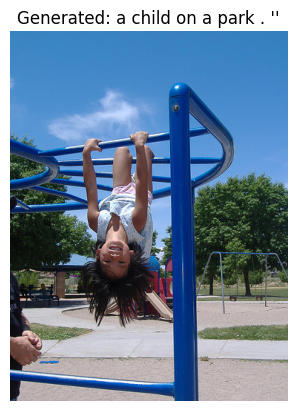

In [ ]:
# --- Helper function to load captions ---
def load_captions(filepath):
    captions_map = defaultdict(list)
    with open(filepath, 'r') as f:
        next(f)
        for line in f:
            image_name, caption = line.strip().split(',', 1)
            captions_map[image_name].append(caption)
    return dict(captions_map)

# --- Load the test set filenames ---
all_captions = load_captions(CAPTIONS_FILE)
!wget -q "https://github.com/Delphboy/karpathy-splits/raw/main/dataset_flickr8k.json?download=" -O dataset_flickr8k.json
with open('dataset_flickr8k.json', 'r') as f:
    karpathy_split = json.load(f)

test_filenames = [img['filename'] for img in karpathy_split['images'] if img['split'] == 'test']

# --- Pick a random image and predict ---
random_image_filename = random.choice(test_filenames)
image_path_to_predict = os.path.join(IMAGE_PATH, random_image_filename)

print(f"Predicting for image: {random_image_filename}")

# Generate the caption
generated_caption = predict_caption(image_path_to_predict)

# Display the image and caption
image = Image.open(image_path_to_predict)
plt.imshow(image)
plt.title(f"Generated: {generated_caption}", wrap=True)
plt.axis("off")
plt.show()